# Water-limited production (winter wheat)

This example runs torchcrop's **Lintul5** model in **water-limited** mode over
an 18-location [Brandenburg winter-wheat dataset](https://github.com/geonextgis/torchcrop/tree/main/docs/examples/data/brandenburg),
then plots the full state and diagnostic trajectories of a few locations
against development stage (DVS).

**Water-limited production** reduces crop growth by soil-water stress (`TRANRF`)
**only**: nitrogen, phosphorus and potassium are kept non-limiting and no
fertiliser is applied. It is configured with two switches:

| Switch             | Value | Effect                                               |
| ------------------ | ----- | ---------------------------------------------------- |
| `crop_params.iopt` | `2`   | Run mode = water-limited → nutrient stress off       |
| `soil_params.irri` | `0`   | Rain-fed → soil water may limit growth (the default) |

Because the crop is rain-fed, dry locations dry the root zone out, `TRANRF`
drops below `1`, and yields fall well below the [potential run](<https://github.com/geonextgis/torchcrop/blob/main/docs/examples/01_potential/potential_(winter_wheat).ipynb>).

The dataset is autumn-sown (`IDPL = 270`) while the weather series start on
1 January, so the model is driven with `start_doy=1` and relies on its internal
**sowing latch** for the pre-sowing spin-up.


## Import libraries


In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from torch.utils.data import Dataset

from torchcrop import (
    CropParameters,
    SoilParameters,
    SiteParameters,
    Lintul5Model,
    WeatherDriver,
)

plt.rcParams["font.family"] = "DeJavu Serif"
plt.rcParams["font.serif"] = "Times New Roman"

DATA_DIR = Path("../data", "brandenburg", "torchcrop")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Prepare dataset and dataloader


In [2]:
class TorchCropDataset(Dataset):
    """Reads per-location weather, soil, and site data for torchcrop.

    Directory layout (under ``DATA_DIR``)::

        weather/<location>.csv   daily forcing, one file per location
        soil/soil.csv            one row per location, indexed by ``location``
        site/site.csv            one row per location, indexed by ``location``

    ``__getitem__`` returns a single sample as a dict with:

        * ``weather`` : ``[T, 8]`` float tensor in torchcrop channel order
          (DOY, davtmp, tmin, tmax, irrad, rain, vp, wind)
        * ``soil``    : dict of scalar floats keyed by ``SoilParameters`` field
        * ``site``    : dict of scalar floats keyed by ``SiteParameters`` field

    Use `collate_torchcrop` as the DataLoader ``collate_fn`` to assemble a
    batch into ready-to-run ``WeatherDriver`` / ``SoilParameters`` /
    ``SiteParameters`` objects.
    """

    # CSV weather columns, in the exact order torchcrop expects them.
    WEATHER_COLS = [
        "Date",          # -> doy
        "TempMean",      # -> davtmp
        "TempMin",       # -> tmin
        "TempMax",       # -> tmax
        "Radiation",     # -> irrad
        "Precipitation", # -> rain
        "VapPressure",   # -> vp
        "Windspeed",     # -> wind
    ]

    # soil.csv column -> SoilParameters field name
    SOIL_MAP = {
        "SMDRY": "wcad",       # air-dry volumetric water content [m³ m⁻³]
        "SMW": "wcwp",         # water content at wilting point [m³ m⁻³]
        "SMFC": "wcfc",        # water content at field capacity [m³ m⁻³]
        "SMO": "wcst",         # water content at saturation [m³ m⁻³]
        "CRAIRC": "crairc",    # critical air content for aeration [m³ m⁻³]
        "SMI": "wci",          # initial root-zone moisture content [m³ m⁻³]
        "SMLOWI": "wci_lower", # initial lower-zone (sub-soil) moisture [m³ m⁻³]
        "RDMSO": "rdmso",      # max rooting depth allowed by the soil [m]
        "RUNFR": "runfr",      # fraction of rainfall lost to surface runoff [0–1]
        "CFEV": "cfev",        # soil-evaporation correction factor [-] (1–4)
        "KSUB": "ksub",        # max percolation rate to deeper layers [mm d⁻¹]
        "NMINS": "nmini",      # initial mineralisable soil organic N [g N m⁻²]
        "PMINS": "pmini",      # initial mineralisable soil organic P [g P m⁻²]
        "KMINS": "kmini",      # initial mineralisable soil organic K [g K m⁻²]
        "RTNMINS": "rtnmins",  # daily N mineralisation fraction [d⁻¹]
        "RTPMINS": "rtpmins",  # daily P mineralisation fraction [d⁻¹]
        "RTKMINS": "rtkmins",  # daily K mineralisation fraction [d⁻¹]
    }

    # site.csv column -> SiteParameters field name
    SITE_MAP = {
        "LATITUDE": "latitude",
        "ALTITUDE": "altitude",
        "IDPL": "idpl",
        "CO2": "co2",
    }

    def __init__(self, weather_dir, soil_dir, site_dir, dtype=torch.float32):
        super().__init__()
        self.weather_dir = Path(weather_dir)
        self.dtype = dtype
        self.soil_data = pd.read_csv(
            os.path.join(soil_dir, "soil.csv")
        ).set_index("location")
        self.site_data = pd.read_csv(
            os.path.join(site_dir, "site.csv")
        ).set_index("location")
        # Locations present in both soil and site tables.
        self.locations = self.soil_data.index.intersection(self.site_data.index)

    def __len__(self):
        return len(self.locations)

    def _load_weather(self, location):
        df = pd.read_csv(
            self.weather_dir / f"{location}.csv", parse_dates=["Date"]
        )
        df = df[self.WEATHER_COLS].copy()
        df["Radiation"] = df["Radiation"] / 1000.0   # kJ -> MJ m-2 d-1
        df["Date"] = df["Date"].dt.dayofyear          # date -> day-of-year
        return torch.as_tensor(df.values, dtype=self.dtype)  # [T, 8]

    def __getitem__(self, idx):
        location = self.locations[idx]

        weather = self._load_weather(location)

        srow = self.soil_data.loc[location]
        soil = {field: float(srow[col]) for col, field in self.SOIL_MAP.items()}

        trow = self.site_data.loc[location]
        site = {field: float(trow[col]) for col, field in self.SITE_MAP.items()}

        return {"weather": weather, "soil": soil, "site": site}


def collate_torchcrop(batch, dtype=torch.float32):
    """Collate samples into batched torchcrop driver/parameter objects.

    Args:
        batch: list of samples produced by `TorchCropDataset.__getitem__`.
        dtype: target dtype for the assembled tensors.

    Returns:
        Tuple ``(weather, soil_params, site_params)`` where ``weather`` is a
        `WeatherDriver` of shape ``[B, T, 8]`` and ``soil_params`` /
        ``site_params`` are batched dataclasses with ``[B]`` scalar fields.
    """
    # Weather: [B, T, 8]
    weather = torch.stack([s["weather"] for s in batch], dim=0).to(dtype)
    weather = WeatherDriver(weather)

    # Soil / site: stack each field across the batch into a [B] tensor.
    soil_fields = batch[0]["soil"].keys()
    soil_kwargs = {
        f: torch.tensor([s["soil"][f] for s in batch], dtype=dtype)
        for f in soil_fields
    }
    soil_params = SoilParameters(**soil_kwargs)

    site_fields = batch[0]["site"].keys()
    site_kwargs = {
        f: torch.tensor([s["site"][f] for s in batch], dtype=dtype)
        for f in site_fields
    }
    site_params = SiteParameters(**site_kwargs)

    return weather, soil_params, site_params

In [3]:
dataset = TorchCropDataset(
    weather_dir=DATA_DIR / "weather",
    soil_dir=DATA_DIR / "soil",
    site_dir=DATA_DIR / "site",
)

print(f"Dataset: {len(dataset)} locations")

Dataset: 18 locations


## Run the model — water-limited (no nitrogen, no fertiliser)

The production level is controlled by two switches:

- `crop_params.iopt` — the crop run mode:

| `iopt` | Mode                      |
| ------ | ------------------------- |
| 1      | Potential (no stress)     |
| 2      | **Water-limited**         |
| 3      | Water + N limited         |
| 4      | Water + N + P + K limited |

- `soil_params.irri` — the irrigation mode (`0` = rain-fed, `1` = automatic
  refill to field capacity, `2` = scheduled table).

For **water-limited production** we set `iopt = 2` (nutrients non-limiting) and
leave `irri = 0` (rain-fed, the default). The only active stress is then the
water-stress factor `TRANRF`, which drops below `1` whenever the root zone
dries out.


In [4]:
# Winter-wheat crop parameters in water-limited mode (IOPT=2): nutrient stress
# is switched off and no fertiliser is applied. Irrigation is left at its
# default (`soil_params.irri = 0`, rain-fed), so soil water is the only stress.
crop_params = CropParameters(crop_name="wheat")
crop_params.iopt = torch.tensor(2.0)

# Assemble all 18 locations into one batch and run a single forward pass.
samples = [dataset[i] for i in range(len(dataset))]
weather, soil_params, site_params = collate_torchcrop(samples)

# Move every tensor input onto the target device.
crop_params = crop_params.to(device=device)
soil_params = soil_params.to(device=device)
site_params = site_params.to(device=device)
weather = weather.to(device=device)

model = Lintul5Model(crop_params, soil_params, site_params).eval().to(device)
with torch.no_grad():
    output = model(weather, start_doy=1)

# Per-location summary at maturity. 
results = pd.DataFrame(
    {
        "location": list(dataset.locations),
        "yield_g_m2": output.yield_.tolist(),
        "max_lai": output.lai.max(dim=1).values.tolist(),
        "final_dvs": output.dvs[:, -1].tolist(),
    }
)
results

,location,yield_g_m2,max_lai,final_dvs
0,0,460.162537,1.800738,2.0
1,1,240.263779,0.724083,2.0
2,2,0.587138,0.466574,2.0
3,3,199.338379,0.628977,2.0
4,4,110.068016,0.781527,2.0
5,5,102.331017,0.932203,2.0
6,6,254.243240,1.137208,2.0
7,7,255.926300,0.858665,2.0
8,8,259.682220,0.898807,2.0
9,9,146.657089,0.722536,2.0


## Visualizing the results

The model returns two per-day trajectories that we visualise the same way:

- **State variables** — `output.states`, a list of `ModelState`
  holding the model's stored pools (biomass, LAI, soil water, nutrient pools, …).
- **Diagnostic variables** — `output.diagnostics`, a list of `DiagnosticState`
  holding the intermediate fluxes and stress factors computed each
  day (TRANRF, RUE, partitioning fractions, transpiration, …).

Each weather series starts on 1 January, but the crop is autumn-sown
(`IDPL = 270`); masking to the sowing latch makes every curve **start at the day
of sowing**. The short near-vertical segment at DVS `0` is the sowing→emergence
interval; DVS then climbs `0 → 1` (anthesis) `→ 2` (maturity).


In [5]:
from matplotlib.lines import Line2D

# Pick five random (reproducible) locations
rng = np.random.default_rng(42)
selected_idx = rng.choice(len(dataset.locations), size=5, replace=False)
locations = [dataset.locations[i] for i in selected_idx]
n_loc = len(locations)
colors = [
    "#1f77b4",  # blue
    "#d62728",  # red
    "#2ca02c",  # green
    "#ff7f0e",  # orange
    "#9467bd",  # purple
]

def mask_until_dvs2(sown_mask, dvs_vals):
    """Boolean mask selecting sown days up to and including maturity (DVS >= 2).

    Args:
        sown_mask: ``[L]`` bool array, ``True`` once the crop is sown.
        dvs_vals:  ``[L]`` development-stage values.

    Returns:
        ``[L]`` bool mask: sown days with index <= the first day DVS reaches 2.
    """
    mature = np.where(dvs_vals >= 2.0)[0]
    cutoff = mature[0] if len(mature) else len(dvs_vals)
    return sown_mask & (np.arange(len(dvs_vals)) <= cutoff)


def plot_trajectories(traj, dvs, sown, field_names, meta, *, title, ncols=4):
    """Plot every channel of ``traj`` against DVS, one line per location.

    A single helper used for both state and diagnostic figures so they share
    the same style, grid layout, labelling and legend.

    Args:
        traj:        ``[B, L, C]`` stacked trajectory array.
        dvs:         ``[B, L]`` development stage (x-axis).
        sown:        ``[B, L]`` sowing latch (> 0 once sown).
        field_names: length-``C`` list naming the channels of ``traj``.
        meta:        ``{field: (label, unit)}`` used for the panel titles.
        title:       figure super-title.
        ncols:       number of subplot columns.
    """
    nrows = int(np.ceil(len(field_names) / ncols))
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(4.2 * ncols, 2.4 * nrows), sharex=True
    )
    axes = axes.ravel()

    for ax, fld in zip(axes, field_names):
        j = field_names.index(fld)
        for c, b in enumerate(selected_idx):
            mask = mask_until_dvs2(sown[b] > 0, dvs[b])
            ax.plot(dvs[b][mask], traj[b, mask, j], color=colors[c], lw=1.2, alpha=0.9)
        label, unit = meta.get(fld, (fld, ""))
        ax.set_title(f"{label} [{unit}]" if unit else label, fontsize=11)
        ax.grid(alpha=0.3)
        ax.margins(x=0.02)

    # Hide unused panels; label the x-axis on the bottom row of plotted panels.
    for ax in axes[len(field_names):]:
        ax.axis("off")
    for ax in axes[max(0, len(field_names) - ncols):len(field_names)]:
        ax.set_xlabel("DVS")

    handles = [Line2D([0], [0], color=colors[i], lw=2) for i in range(n_loc)]
    fig.legend(
        handles,
        [str(loc) for loc in locations],
        title="Location",
        loc="lower center",
        ncol=n_loc,
        fontsize=12,
        bbox_to_anchor=(0.5, 0.01),
        frameon=False,
    )
    fig.suptitle(title, fontsize=13)
    fig.tight_layout(rect=[0, 0.04, 1, 0.99])
    plt.show()

### State variables vs DVS

Stack the per-day `ModelState` snapshots into a `[B, T+1, C]` array and plot
every stored state variable against DVS with the shared helper.


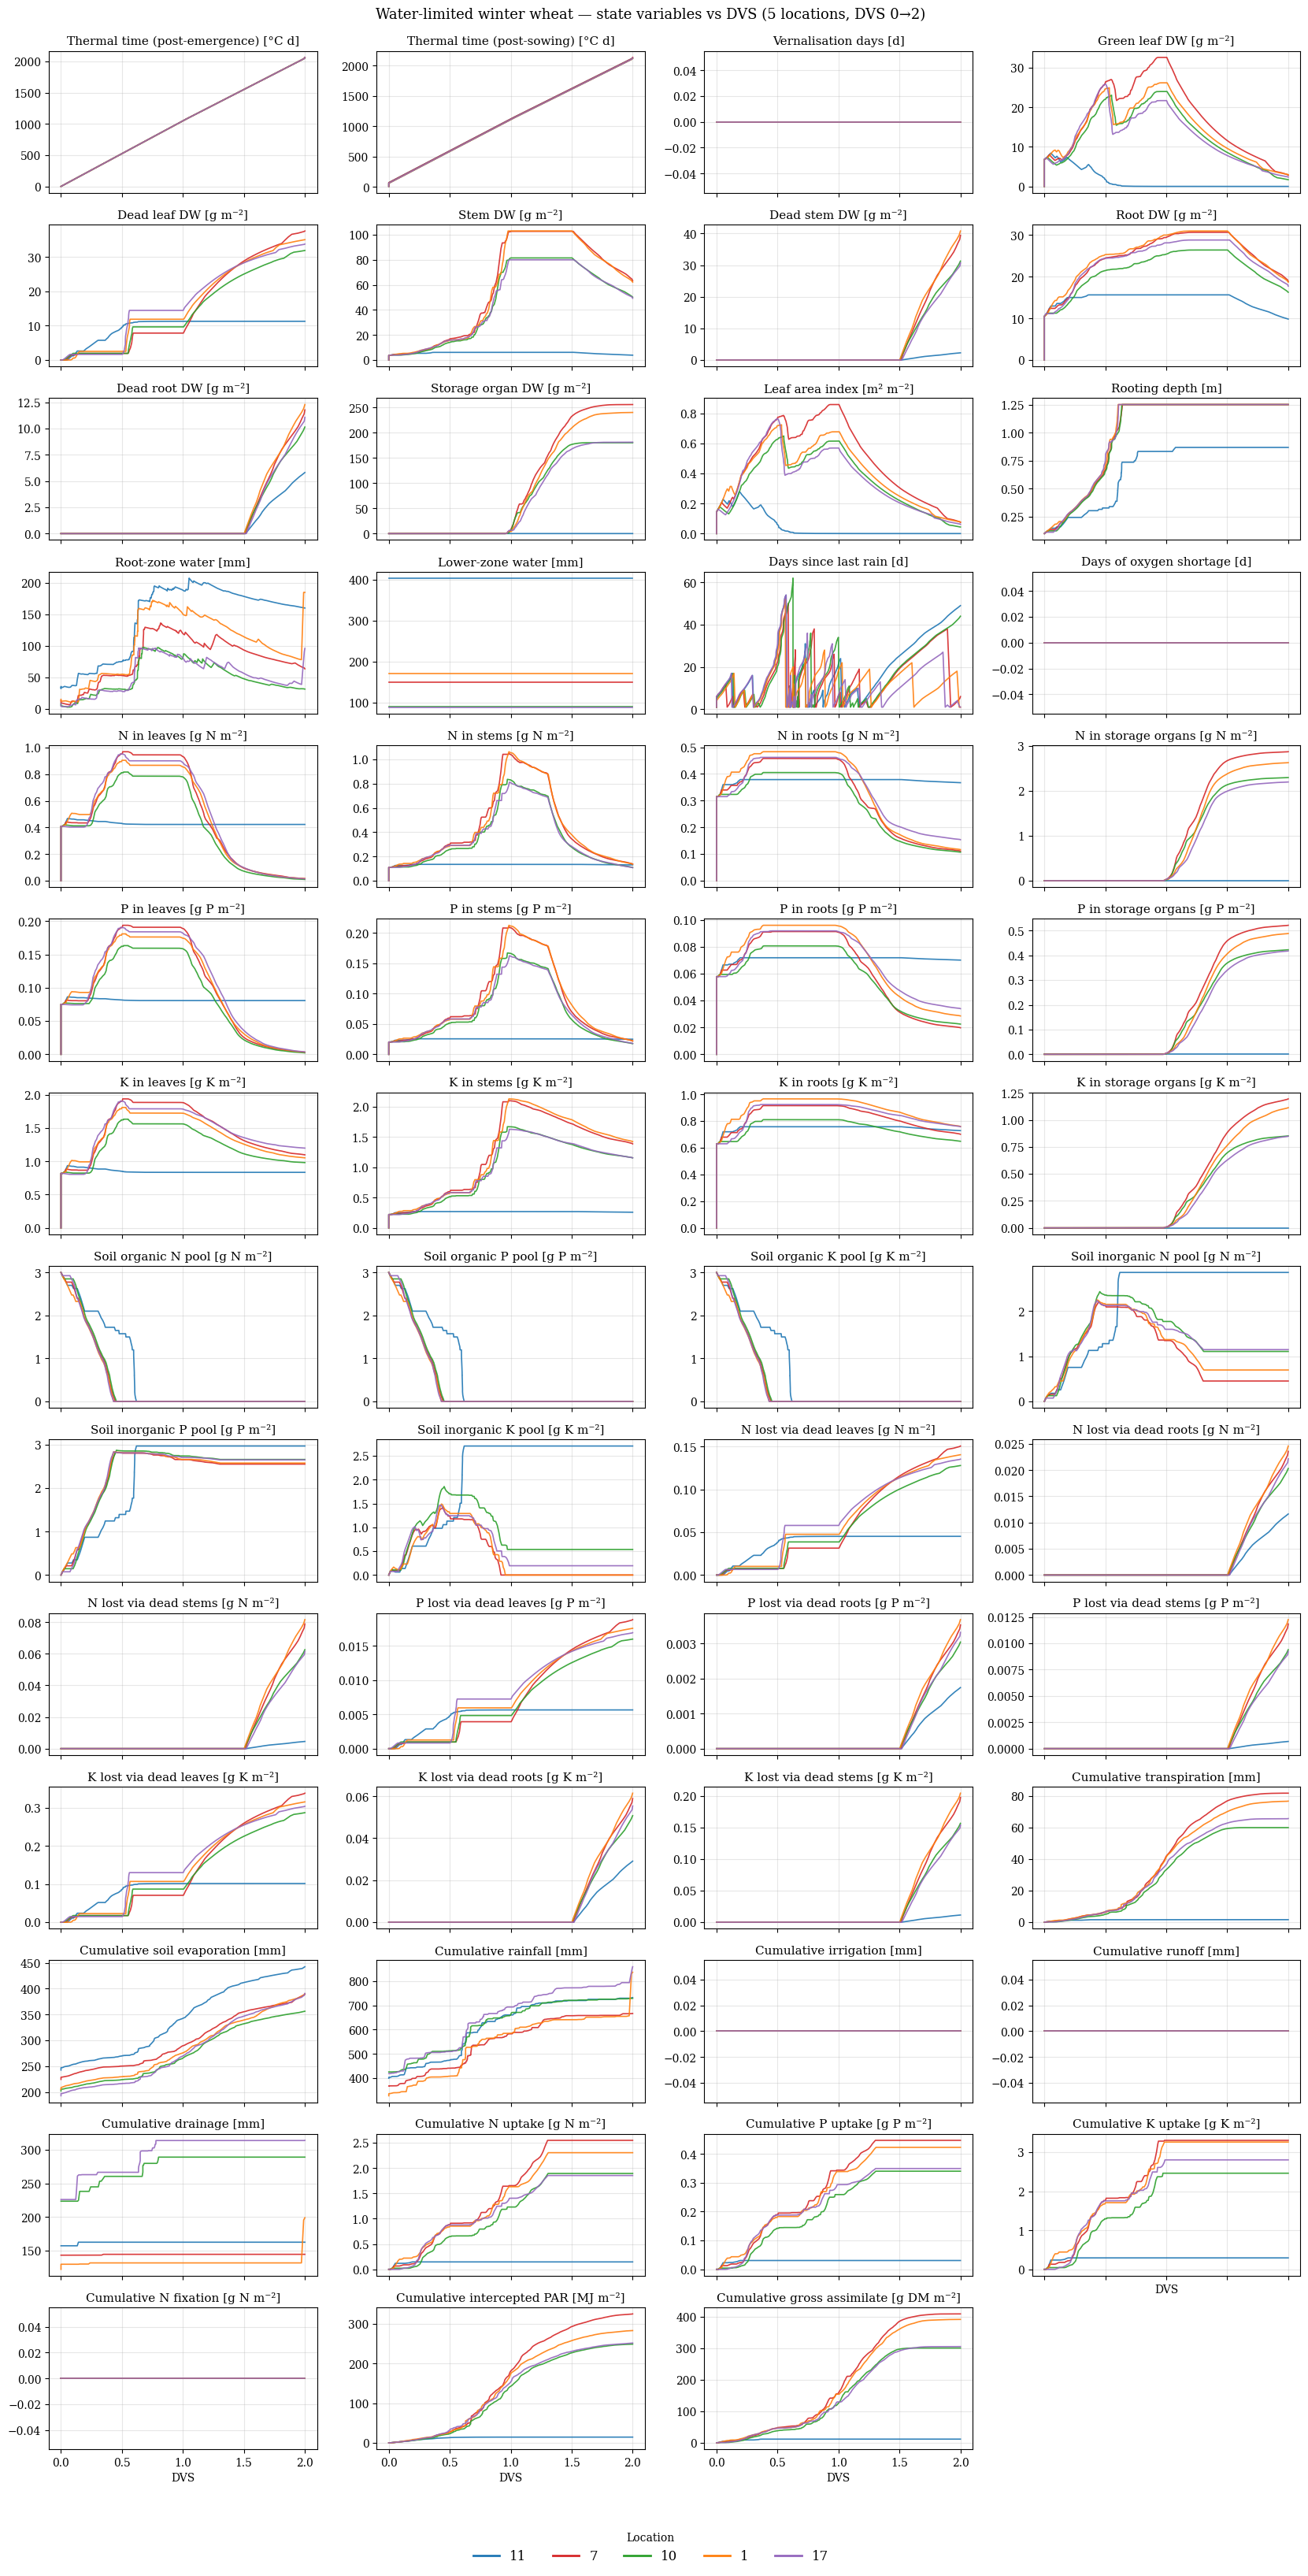

In [8]:
# Label + unit for each ModelState field.
STATE_META = {
    "tsum": ("Thermal time (post-emergence)", "°C d"),
    "tsump": ("Thermal time (post-sowing)", "°C d"),
    "vern": ("Vernalisation days", "d"),
    "wlv": ("Green leaf DW", "g m⁻²"),
    "wlvd": ("Dead leaf DW", "g m⁻²"),
    "wst": ("Stem DW", "g m⁻²"),
    "wstd": ("Dead stem DW", "g m⁻²"),
    "wrt": ("Root DW", "g m⁻²"),
    "wrtd": ("Dead root DW", "g m⁻²"),
    "wso": ("Storage organ DW", "g m⁻²"),
    "lai": ("Leaf area index", "m² m⁻²"),
    "rootd": ("Rooting depth", "m"),
    "wa": ("Root-zone water", "mm"),
    "wa_lower": ("Lower-zone water", "mm"),
    "dslr": ("Days since last rain", "d"),
    "dsos": ("Days of oxygen shortage", "d"),
    "anlv": ("N in leaves", "g N m⁻²"),
    "anst": ("N in stems", "g N m⁻²"),
    "anrt": ("N in roots", "g N m⁻²"),
    "anso": ("N in storage organs", "g N m⁻²"),
    "aplv": ("P in leaves", "g P m⁻²"),
    "apst": ("P in stems", "g P m⁻²"),
    "aprt": ("P in roots", "g P m⁻²"),
    "apso": ("P in storage organs", "g P m⁻²"),
    "aklv": ("K in leaves", "g K m⁻²"),
    "akst": ("K in stems", "g K m⁻²"),
    "akrt": ("K in roots", "g K m⁻²"),
    "akso": ("K in storage organs", "g K m⁻²"),
    "nmin": ("Soil organic N pool", "g N m⁻²"),
    "pmin": ("Soil organic P pool", "g P m⁻²"),
    "kmin": ("Soil organic K pool", "g K m⁻²"),
    "nmint": ("Soil inorganic N pool", "g N m⁻²"),
    "pmint": ("Soil inorganic P pool", "g P m⁻²"),
    "kmint": ("Soil inorganic K pool", "g K m⁻²"),
    "nlossl": ("N lost via dead leaves", "g N m⁻²"),
    "nlossr": ("N lost via dead roots", "g N m⁻²"),
    "nlosss": ("N lost via dead stems", "g N m⁻²"),
    "plossl": ("P lost via dead leaves", "g P m⁻²"),
    "plossr": ("P lost via dead roots", "g P m⁻²"),
    "plosss": ("P lost via dead stems", "g P m⁻²"),
    "klossl": ("K lost via dead leaves", "g K m⁻²"),
    "klossr": ("K lost via dead roots", "g K m⁻²"),
    "klosss": ("K lost via dead stems", "g K m⁻²"),
    "tran_cum": ("Cumulative transpiration", "mm"),
    "evap_cum": ("Cumulative soil evaporation", "mm"),
    "rain_cum": ("Cumulative rainfall", "mm"),
    "irrig_cum": ("Cumulative irrigation", "mm"),
    "runoff_cum": ("Cumulative runoff", "mm"),
    "drain_cum": ("Cumulative drainage", "mm"),
    "nuptr_cum": ("Cumulative N uptake", "g N m⁻²"),
    "puptr_cum": ("Cumulative P uptake", "g P m⁻²"),
    "kuptr_cum": ("Cumulative K uptake", "g K m⁻²"),
    "nfixtr_cum": ("Cumulative N fixation", "g N m⁻²"),
    "parint_cum": ("Cumulative intercepted PAR", "MJ m⁻²"),
    "gtotal_cum": ("Cumulative gross assimilate", "g DM m⁻²"),
}

# Stack the per-day ModelState snapshots into a [B, T+1, C] array.
field_names = output.states[0].field_names
state_traj = torch.stack([s.stack() for s in output.states], dim=1).cpu().numpy()  # [B, T+1, C]
dvs_traj = output.dvs.cpu().numpy()  # [B, T+1]
sown_traj = torch.stack([s.sown for s in output.states], dim=1).cpu().numpy()  # [B, T+1]

# DVS itself and the binary sowing latch are not informative state curves.
plot_fields = [f for f in field_names if f not in ("dvs", "sown")]
plot_idx = [field_names.index(f) for f in plot_fields]

plot_trajectories(
    state_traj[:, :, plot_idx],
    dvs_traj,
    sown_traj,
    plot_fields,
    STATE_META,
    title="Water-limited winter wheat — state variables vs DVS (5 locations, DVS 0→2)\n",
)

### Diagnostic variables vs DVS

The diagnostics are the intermediate fluxes and stress factors computed each
day — stress factors (`TRANRF`, NNI, …), photosynthesis drivers (`RUE`,
`GTOTAL`), light interception, phenology drivers, water/nutrient fluxes and
partitioning fractions.


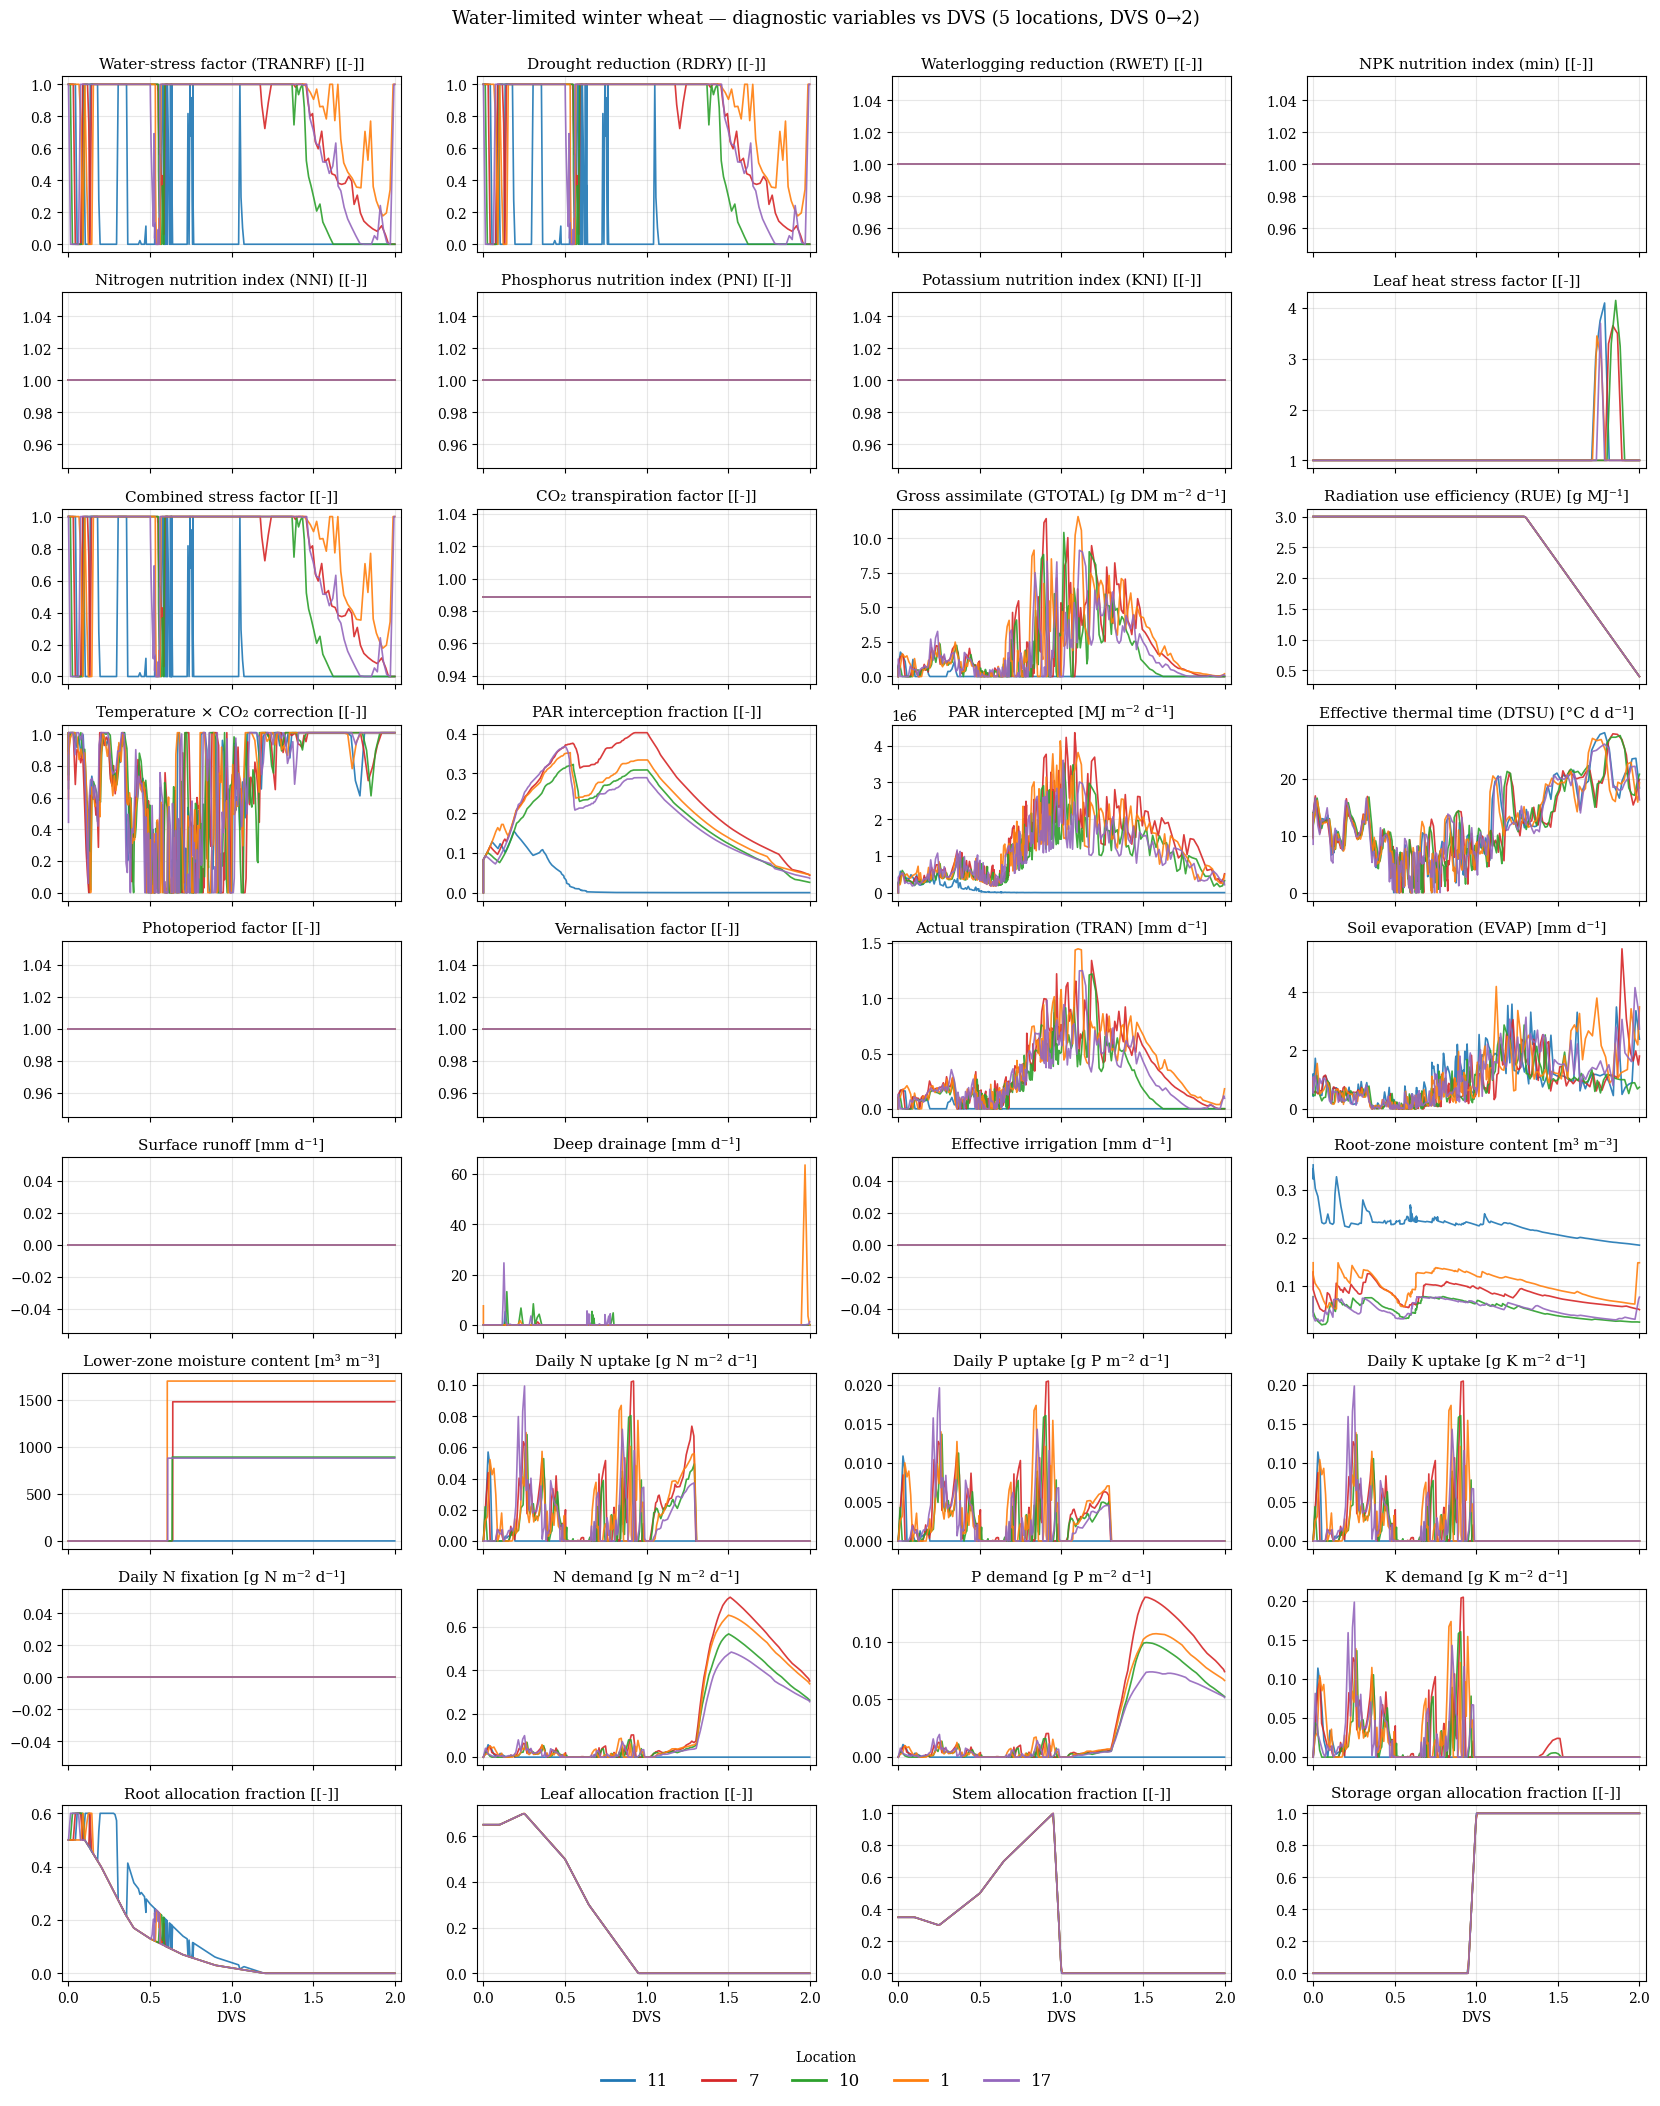

In [9]:
# Label + unit for each DiagnosticState field.
DIAG_META = {
    # Stress factors
    "tranrf": ("Water-stress factor (TRANRF)", "[-]"),
    "rdry": ("Drought reduction (RDRY)", "[-]"),
    "rwet": ("Waterlogging reduction (RWET)", "[-]"),
    "nstress": ("NPK nutrition index (min)", "[-]"),
    "nni": ("Nitrogen nutrition index (NNI)", "[-]"),
    "pni": ("Phosphorus nutrition index (PNI)", "[-]"),
    "kni": ("Potassium nutrition index (KNI)", "[-]"),
    "leaf_heat_factor": ("Leaf heat stress factor", "[-]"),
    "combined_stress": ("Combined stress factor", "[-]"),
    "co2_factor": ("CO₂ transpiration factor", "[-]"),
    # Photosynthesis / growth drivers
    "gtotal": ("Gross assimilate (GTOTAL)", "g DM m⁻² d⁻¹"),
    "rue": ("Radiation use efficiency (RUE)", "g MJ⁻¹"),
    "rtmco": ("Temperature × CO₂ correction", "[-]"),
    # Light / canopy
    "frac_intercepted": ("PAR interception fraction", "[-]"),
    "parint": ("PAR intercepted", "MJ m⁻² d⁻¹"),
    # Phenology drivers
    "dtsu": ("Effective thermal time (DTSU)", "°C d d⁻¹"),
    "photofac": ("Photoperiod factor", "[-]"),
    "vernfac": ("Vernalisation factor", "[-]"),
    # Water fluxes
    "tran": ("Actual transpiration (TRAN)", "mm d⁻¹"),
    "evap": ("Soil evaporation (EVAP)", "mm d⁻¹"),
    "runoff": ("Surface runoff", "mm d⁻¹"),
    "drain": ("Deep drainage", "mm d⁻¹"),
    "rirr": ("Effective irrigation", "mm d⁻¹"),
    "smact": ("Root-zone moisture content", "m³ m⁻³"),
    "smactl": ("Lower-zone moisture content", "m³ m⁻³"),
    # Nutrient fluxes
    "nuptr": ("Daily N uptake", "g N m⁻² d⁻¹"),
    "puptr": ("Daily P uptake", "g P m⁻² d⁻¹"),
    "kuptr": ("Daily K uptake", "g K m⁻² d⁻¹"),
    "nfixtr": ("Daily N fixation", "g N m⁻² d⁻¹"),
    "n_demand": ("N demand", "g N m⁻² d⁻¹"),
    "p_demand": ("P demand", "g P m⁻² d⁻¹"),
    "k_demand": ("K demand", "g K m⁻² d⁻¹"),
    # Partitioning fractions
    "fr": ("Root allocation fraction", "[-]"),
    "fl": ("Leaf allocation fraction", "[-]"),
    "fs": ("Stem allocation fraction", "[-]"),
    "fo": ("Storage organ allocation fraction", "[-]"),
}

# Stack the per-day DiagnosticState snapshots into a [B, T, C] array.
diag_field_names = output.diagnostics[0].field_names
diag_traj = torch.stack(
    [s.stack() for s in output.diagnostics], dim=1
).cpu().numpy()  # [B, T, C]

plot_trajectories(
    diag_traj,
    dvs_traj[:, :-1],
    sown_traj[:, :-1],
    diag_field_names,
    DIAG_META,
    title="Water-limited winter wheat — diagnostic variables vs DVS (5 locations, DVS 0→2)\n",
)